In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Path to your file in Google Drive
file_path = '/content/drive/MyDrive/artikel_manual_celine.csv'

import pandas as pd
df = pd.read_csv(file_path)
df.head()


In [ ]:
from google.colab import files
import pandas as pd
import io

# Upload the Excel file
uploaded = files.upload()

# Get the filename automatically
filename = list(uploaded.keys())[0]

# Read two sheets into two separate DataFrames
df1 = pd.read_excel(io.BytesIO(uploaded[filename]), sheet_name="Case")
df2 = pd.read_excel(io.BytesIO(uploaded[filename]), sheet_name="Main")

# Preview
print("Sheet1 Shape:", df1.shape)
print("Sheet2 Shape:", df2.shape)

display(df1.head())
display(df2.head())


Saving artikel_manual_celine.xlsx to artikel_manual_celine (2).xlsx
Sheet1 Shape: (11, 3)
Sheet2 Shape: (32, 9)


,Case ID,Case,Penjelasan
0,C01,Cara Pelaksanaan di Lapangan,"Berita tentang bagaimana makanan disiapkan, di..."
1,C02,Pembahasan Soal Anggaran & Dana,Berita yang membahas semua hal tentang uang: b...
2,C03,Tujuan Program & Siapa Penerimanya,Berita yang menjelaskan kenapa program ini ada...
3,C04,Isi Makanan dan Gizinya,"Berita tentang menu makanannya apa saja, kandu..."
4,C05,Uji Coba di Berbagai Daerah,Berita tentang percobaan atau simulasi program...


,Case ID,Case,Newsroom,Tanggal,Judul,Konten,Link,Kota,Tone
0,C01,Cara Pelaksanaan di Lapangan,Kompas.com\t,2024-11-01,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,"JAKARTA, KOMPAS.com - Pemerintah terus menyiap...",Persiapan Makan Bergizi Gratis: Sudah Simulasi...,Jakarta,Netral
1,C02,Proyeksi dan Alokasi Anggaran,Kompas.com\t,2025-08-13,Sri Mulyani Ungkap Anggaran Program MBG Lebih ...,"JAKARTA, KOMPAS.com - Menteri Keuangan Sri Mul...",Sri Mulyani Ungkap Anggaran Program MBG Lebih ...,Jakarta,Netral
2,C01,Cara Pelaksanaan di Lapangan,Kompas.com\t,2025-08-13,Target 20 Juta Penerima Makan Bergizi Gratis D...,KOMPAS.com – Kepala Badan Gizi Nasional (BGN) ...,Target 20 Juta Penerima Makan Bergizi Gratis D...,Jakarta,Netral
3,C11,Suara & Tanggapan Masyarakat,Liputan6.com,2025-01-06,"SD di Medan Gelar Makan Bergizi Gratis, Siswa:...","Liputan6.com, Medan - Program Makan Sehat Berg...","SD di Medan Gelar Makan Bergizi Gratis, Siswa:...","Medan, Sumatera Utara",Positif
4,C06,Dampak ke Ekonomi dan UMKM,Kompas.com\t,2025-03-19,"MBG Bisa Ciptakan 1,9 Juta Lapangan Kerja, Luh...","JAKARTA, KOMPAS.com - Dewan Ekonomi Nasional (...","MBG Bisa Ciptakan 1,9 Juta Lapangan Kerja, Luh...",Jakarta,Positif


In [ ]:
### 🔧 Implementation: Load Dataset
```python
import pandas as pd

# Preview dataset
print("Dataset Shape:", df1.shape)
print("Dataset Shape:", df2.shape)
df1.head()
df2.head()
```

# Next Module: **3. Preprocessing Text Data**

In [ ]:
### 🔧 Implementation
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


# Example: use only first article for demonstration
text = df2['Konten'][0]


# Lowercase
text = text.lower()


# Remove punctuation & numbers
text = re.sub(r'[^a-zA-Z\s]', '', text)


# Tokenization
tokens = word_tokenize(text)


# Remove stopwords
stop_words = set(stopwords.words('indonesian'))
filtered_tokens = [w for w in tokens if w not in stop_words]


print("Original Text (shortened):", df2['Konten'][0][:300])
print("\nProcessed Tokens:", filtered_tokens[:30])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Original Text (shortened): JAKARTA, KOMPAS.com - Pemerintah terus menyiapkan dan menguji coba program makan bergizi gratis yang rencananya akan dimulai pada 2 Januari 2025. Terbaru, pemerintah memiliki opsi untuk mengganti susu kemasan menjadi susu cair sebagai alternatif pengganti dalam menu program makan bergizi gratis. Men

Processed Tokens: ['jakarta', 'kompascom', 'pemerintah', 'menguji', 'coba', 'program', 'makan', 'bergizi', 'gratis', 'rencananya', 'januari', 'terbaru', 'pemerintah', 'memiliki', 'opsi', 'mengganti', 'susu', 'kemasan', 'susu', 'cair', 'alternatif', 'pengganti', 'menu', 'program', 'makan', 'bergizi', 'gratis', 'menteri', 'sekretaris', 'negara']


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

# Example: Apply TF-IDF on the 'Content' column of your dataset
# (replace 'Content' with your actual column name if different)
documents = df2['Konten'].astype(str).tolist()

# Get Indonesian stopwords
stop_words = set(stopwords.words('indonesian'))

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=20, ngram_range=(1,2), stop_words=list(stop_words))
tfidf_matrix = vectorizer.fit_transform(documents)

# Get feature names and scores
feature_names = vectorizer.get_feature_names_out()
dense = tfidf_matrix.todense()
denselist = dense.tolist()

# Create a DataFrame of TF-IDF scores
tfidf_df = pd.DataFrame(denselist, columns=feature_names)

print("Top TF-IDF Features across all documents:")
print(tfidf_df.sum().sort_values(ascending=False).head(20))

Top TF-IDF Features across all documents:
program           8.753301
mbg               8.383029
makanan           7.513167
anak              7.448690
makan             6.094812
bergizi           5.378527
sekolah           5.013915
gizi              4.743646
gratis            4.673093
makan bergizi     4.375018
siswa             4.058666
bergizi gratis    4.018241
anggaran          3.883868
juta              3.474604
000               3.401372
triliun           3.290931
pemerintah        3.163490
indonesia         2.931050
pendidikan        2.139346
guru              1.134060
dtype: float64


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords # Import stopwords

# Take the 'content' column for analysis
texts = df2['Konten'].dropna().tolist()

# Get Indonesian stopwords
stop_words = set(stopwords.words('indonesian'))

# Create CountVectorizer for bigrams & trigrams
vectorizer = CountVectorizer(ngram_range=(2,3), stop_words=list(stop_words), max_features=10)
X = vectorizer.fit_transform(texts)

# Get top bigrams/trigrams
ngrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1
ngram_freq = pd.DataFrame({'ngram': ngrams, 'count': counts}).sort_values(by='count', ascending=False)

ngram_freq

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


,ngram,count
4,makan bergizi,98
1,bergizi gratis,93
5,makan bergizi gratis,85
7,program makan,54
0,anak anak,47
8,program makan bergizi,47
9,program mbg,37
3,gratis mbg,31
2,bergizi gratis mbg,31
6,penerima manfaat,27


from matplotlib import pyplot as plt
ngram_freq['count'].plot(kind='hist', bins=20, title='count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
ngram_freq['count'].plot(kind='line', figsize=(8, 4), title='count')
plt.gca().spines[['top', 'right']].set_visible(False)

## 5. Keyword Extraction

Now that we have preprocessed the text, we can explore different keyword extraction techniques to identify the most important terms in the articles.

### 5.1 TF-IDF (Term Frequency-Inverse Document Frequency)

We have already calculated the TF-IDF scores. We can use these scores to identify important keywords for each document or across the entire corpus.

### 5.2 TextRank

TextRank is a graph-based algorithm that can be used for keyword extraction. It is based on the idea that important words are those that are related to many other important words in the text.

### 5.3 RAKE (Rapid Automatic Keyword Extraction)

RAKE is another algorithm for keyword extraction that identifies keywords based on the frequency of words and the distance between them.

In [ ]:
# Example: Extract keywords for the first document using TF-IDF
document_index = 0
tfidf_scores = tfidf_df.iloc[document_index]
sorted_keywords = tfidf_scores.sort_values(ascending=False)

print(f"Top TF-IDF keywords for document {document_index + 1}:")
print(sorted_keywords.head(10))

Top TF-IDF keywords for document 1:
000               0.639772
makan             0.285669
program           0.277141
makan bergizi     0.257102
anak              0.255778
bergizi           0.249427
gratis            0.221713
bergizi gratis    0.221713
indonesia         0.212450
pemerintah        0.166370
Name: 0, dtype: float64


## 6. Text Embeddings

Text embeddings are numerical representations of text that capture semantic meaning. We can use embeddings to analyze the similarity between documents or words.

### 6.1 Word Embeddings (e.g., Word2Vec, GloVe)

Word embeddings represent individual words as vectors.

### 6.2 Document Embeddings (e.g., Doc2Vec, Sentence-BERT)

Document embeddings represent entire documents as vectors.

### 6.3 Using Pre-trained Embeddings

We can use pre-trained embeddings to leverage knowledge from large datasets.

In [ ]:
# Example: Placeholder for TextRank and RAKE implementation
print("Implementing TextRank and RAKE in the next steps...")

Implementing TextRank and RAKE in the next steps...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

# Example: Apply TF-IDF on the 'Content' column of your dataset
# (replace 'Content' with your actual column name if different)
documents = df2['Konten'].astype(str).tolist()

# Get Indonesian stopwords
stop_words = set(stopwords.words('indonesian'))

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=20, ngram_range=(1,2), stop_words=list(stop_words))
tfidf_matrix = vectorizer.fit_transform(documents)

# Get feature names and scores
feature_names = vectorizer.get_feature_names_out()
dense = tfidf_matrix.todense()
denselist = dense.tolist()

# Create a DataFrame of TF-IDF scores
import pandas as pd
tfidf_df = pd.DataFrame(denselist, columns=feature_names)

print("Top TF-IDF Features across all documents:")
print(tfidf_df.sum().sort_values(ascending=False).head(20))

Top TF-IDF Features across all documents:
program           8.753301
mbg               8.383029
makanan           7.513167
anak              7.448690
makan             6.094812
bergizi           5.378527
sekolah           5.013915
gizi              4.743646
gratis            4.673093
makan bergizi     4.375018
siswa             4.058666
bergizi gratis    4.018241
anggaran          3.883868
juta              3.474604
000               3.401372
triliun           3.290931
pemerintah        3.163490
indonesia         2.931050
pendidikan        2.139346
guru              1.134060
dtype: float64


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [ ]:
import re
import pandas as pd
import nltk
from collections import Counter

nltk.download("punkt")

# Define lemma roots
lemmas = ["racun", "basi", "korban", "kejang"]

# Regex patterns to catch variations of each lemma
patterns = {lemma: re.compile(rf"\b\w*{lemma}\w*\b", re.IGNORECASE) for lemma in lemmas}

# Function: extract sentences + matched variations
def find_variations(text, patterns):
    if pd.isna(text):
        return []
    found = []
    sentences = nltk.sent_tokenize(text)
    for sent in sentences:
        for lemma, pattern in patterns.items():
            matches = pattern.findall(sent)
            if matches:
                found.append((lemma, sent.strip(), matches))
    return found

# Apply to dataset
df2['lemma_sentences'] = df2['Konten'].apply(lambda x: find_variations(x, patterns))

# Flatten results for frequency summary
all_matches = []
for row in df2['lemma_sentences']:
    for lemma, sent, matches in row:
        all_matches.extend([(lemma, m.lower()) for m in matches])

# Count frequency per lemma root
lemma_counts = Counter([lemma for lemma, _ in all_matches])

# Count frequency per variation
variation_counts = Counter([match for _, match in all_matches])

# Convert to DataFrames for readability
df_lemma_summary = pd.DataFrame(lemma_counts.items(), columns=["lemma_root", "count"]).sort_values(by="count", ascending=False)
df_variation_summary = pd.DataFrame(variation_counts.items(), columns=["variation", "count"]).sort_values(by="count", ascending=False)

print("🔹 Frequency per Lemma Root:")
display(df_lemma_summary)

print("🔹 Frequency per Word Variation:")
display(df_variation_summary)

# Show sentences with matches (sample 5)
df_lemma_sentences = df2[df2['lemma_sentences'].str.len() > 0][['Judul', 'lemma_sentences']]
display(df_lemma_sentences.head(5))

🔹 Frequency per Lemma Root:


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,lemma_root,count
1,racun,32
0,basi,17
2,korban,14


🔹 Frequency per Word Variation:


,variation,count
1,keracunan,31
0,basi,16
2,korban,13
3,korbannya,1
4,berbasis,1
5,meracuni,1


,Judul,lemma_sentences
0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,"[(basi, Salah satu opsi yang disiapkan adalah ..."
5,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,"[(basi, Makanan yang seharusnya menjadi solusi..."
7,72 Katering Kota Kediri Jadi Korban Penipuan M...,"[(korban, Kediri - Puluhan pengusaha katering ..."
9,Seratusan Siswa 3 SMP di Mlati Diduga Keracuna...,"[(racun, Sleman - Polresta Sleman memeriksa Sa..."
12,Makan Bergizi Gratis Tetap Jalan Meski Libur S...,"[(basi, Gimana caranya (diantar ke rumah), wak..."


In [ ]:
import re
import pandas as pd
import nltk
from collections import Counter

nltk.download("punkt")

# Define lemma roots
lemmas = ["racun", "basi", "korban", "kejang"]

# Regex patterns to catch variations of each lemma
patterns = {lemma: re.compile(rf"\b\w*{lemma}\w*\b", re.IGNORECASE) for lemma in lemmas}

# Function: extract sentences + matched variations
def find_variations(text, patterns):
    if pd.isna(text):
        return []
    found = []
    sentences = nltk.sent_tokenize(text)
    for sent in sentences:
        for lemma, pattern in patterns.items():
            matches = pattern.findall(sent)
            if matches:
                found.append((lemma, sent.strip(), matches))
    return found

# Apply to dataset
df2['lemma_sentences'] = df2['Konten'].apply(lambda x: find_variations(x, patterns))

# --- 1) Lemma frequency summary ---
all_matches = []
for row in df2['lemma_sentences']:
    for lemma, sent, matches in row:
        all_matches.extend([(lemma, m.lower()) for m in matches])

lemma_counts = Counter([lemma for lemma, _ in all_matches])
df_lemma_summary = pd.DataFrame(
    lemma_counts.items(), columns=["lemma_root", "count"]
).sort_values(by="count", ascending=False)

# --- 2) Variation frequency summary ---
variation_counts = Counter([match for _, match in all_matches])
df_variation_summary = pd.DataFrame(
    variation_counts.items(), columns=["variation", "count"]
).sort_values(by="count", ascending=False)

# --- 3) Sentence-level matches ---
rows = []
for i, row in df2.iterrows():
    for lemma, sent, matches in row['lemma_sentences']:
        for m in matches:
            rows.append({
                "Judul": row['Judul'],
                "lemma_root": lemma,
                "match": m,
                "sentence": sent
            })

df_sentence_matches = pd.DataFrame(rows)


# df_lemma_summary
# df_variation_summary
# df_sentence_matches


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
df_lemma_summary

,lemma_root,count
1,racun,32
0,basi,17
2,korban,14


In [ ]:
df_variation_summary


,variation,count
1,keracunan,31
0,basi,16
2,korban,13
3,korbannya,1
4,berbasis,1
5,meracuni,1


In [ ]:
df_sentence_matches

,Judul,lemma_root,match,sentence
0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,basi,basi,Salah satu opsi yang disiapkan adalah mengemas...
1,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,"Makanan yang seharusnya menjadi solusi gizi, j..."
2,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,Kasus makanan basi yang ditemukan dalam distri...
3,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,Menurut dokter dan Ahli Gizi Masyarakat DR. dr...
4,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,“Makanan basi itu bukan makanan yang layak unt...
...,...,...,...,...
58,Seberapa Konsisten Program Makan Bergizi Grati...,racun,keracunan,Siapa yang akan bertanggung jawab dan bagaiman...
59,Menu MBG di Dompu Dibuang ke Tong Sampah gegar...,basi,basi,"Musababnya, makanan yang dibagikan tidak layak..."
60,Menu MBG di Dompu Dibuang ke Tong Sampah gegar...,basi,basi,Foto makanan basi yang diterima siswa SDN 9 Do...
61,Menu MBG di Dompu Dibuang ke Tong Sampah gegar...,basi,basi,"Kepala SDN 9 Dompu, Yati Kusmiyanti, membenark..."


In [ ]:
df_sentence_matches.head()

,Judul,lemma_root,match,sentence
0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,basi,basi,Salah satu opsi yang disiapkan adalah mengemas...
1,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,"Makanan yang seharusnya menjadi solusi gizi, j..."
2,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,Kasus makanan basi yang ditemukan dalam distri...
3,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,Menurut dokter dan Ahli Gizi Masyarakat DR. dr...
4,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,“Makanan basi itu bukan makanan yang layak unt...


In [ ]:
# Explode matches into flat table
rows = []
for i, row in df2.iterrows():
    for lemma, sent, matches in row['lemma_sentences']:
        for m in matches:
            rows.append({
                "Judul": row['Judul'],
                "lemma_root": lemma,
                "match": m,
                "sentence": sent
            })

df_matches = pd.DataFrame(rows)
display(df_matches.head(10))


,Judul,lemma_root,match,sentence
0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,basi,basi,Salah satu opsi yang disiapkan adalah mengemas...
1,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,"Makanan yang seharusnya menjadi solusi gizi, j..."
2,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,Kasus makanan basi yang ditemukan dalam distri...
3,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,Menurut dokter dan Ahli Gizi Masyarakat DR. dr...
4,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,“Makanan basi itu bukan makanan yang layak unt...
5,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,racun,keracunan,Jadi itu sudah pasti dampaknya bisa menimbulka...
6,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,"Ia juga menekankan, bau yang tidak sedap dari ..."
7,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,Ketika anak-anak enggan mengonsumsi menu terse...
8,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,“Jangan sampai nanti munculnya adalah food was...
9,Keluhan Makanan Basi di Menu Makan Bergizi Gra...,basi,basi,"Jika sudah basi, umumnya makanan tersebut suda..."


In [ ]:
df_matches.shape

(63, 4)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords

# Get Indonesian stopwords
stop_words = set(stopwords.words('indonesian'))

# Use bigrams and trigrams
vectorizer = CountVectorizer(ngram_range=(2,3), stop_words=list(stop_words))
X = vectorizer.fit_transform(df2['Konten'].dropna())

# Get all n-grams
ngrams = vectorizer.get_feature_names_out()

# Search for n-grams containing "beracun" or "korban"
target_terms = ["beracun", "korban"]
matches = [ng for ng in ngrams if any(term in ng for term in target_terms)]

print("N-grams containing 'beracun' or 'korban':")
print(matches)

N-grams containing 'beracun' or 'korban':
['adu mulut korban', 'ajakan bergabung korban', 'bergabung korban', 'bergabung korban ditarik', 'demam korban', 'demam korban keterangan', 'hukum korban', 'hukum korban danna', 'iming iming korban', 'iming korban', 'iming korban tergiur', 'juta nm korban', 'katering korbannya', 'katering korbannya uang', 'kediri mengaku korban', 'kejelasan korban', 'kejelasan korban menggeruduk', 'korban berkumpul', 'korban berkumpul berupaya', 'korban curiga', 'korban curiga tindak', 'korban danna', 'korban danna harly', 'korban dh', 'korban dh mengalami', 'korban diharuskan', 'korban diharuskan membayar', 'korban diiming', 'korban diiming imingi', 'korban ditarik', 'korban ditarik uang', 'korban keterangan', 'korban keterangan wali', 'korban menggeruduk', 'korban menggeruduk pokmas', 'korban nm', 'korban nm 45', 'korban oknum', 'korban oknum pokmas', 'korban penipuan', 'korban penipuan tertipu', 'korban tergiur', 'korban tergiur pokmas', 'korbannya uang', 'ko

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import pandas as pd

# Target lemma roots
target_terms = ["racun", "beracun", "basi", "korban", "kejang"]

# Get Indonesian stopwords
stop_words = set(stopwords.words('indonesian'))

# Use bigrams and trigrams
vectorizer = CountVectorizer(ngram_range=(2,3), stop_words=list(stop_words))
X = vectorizer.fit_transform(df2['Konten'].dropna())

# Map n-grams to frequencies
ngram_counts = X.sum(axis=0).A1
ngram_freq = dict(zip(vectorizer.get_feature_names_out(), ngram_counts))

# Filter only those containing target terms
matches = {ng: count for ng, count in ngram_freq.items()
           if any(term in ng for term in target_terms)}

# Convert to DataFrame
df_ngram_matches = pd.DataFrame(matches.items(), columns=["ngram", "count"]) \
                    .sort_values(by="count", ascending=False)

print("🔹 N-grams containing target words:")
display(df_ngram_matches.head(15))


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


🔹 N-grams containing target words:


,ngram,count
183,makanan basi,8
58,gejala keracunan,7
200,mengalami gejala keracunan,5
21,basi makanan,4
122,keracunan massal,4
234,penyebab keracunan,4
119,keracunan makanan,2
53,dugaan keracunan,2
125,keracunan massal siswa,2
189,makanan basi makanan,2


In [ ]:
# Split ngrams into individual tokens and explode into rows
df_ngram_split = df_ngram_matches.copy()
df_ngram_split["tokens"] = df_ngram_split["ngram"].str.split()

# Explode so each token gets its own row
df_ngram_split = df_ngram_split.explode("tokens").reset_index(drop=True)

display(df_ngram_split.head(15))


,ngram,count,tokens
0,makanan basi,8,makanan
1,makanan basi,8,basi
2,gejala keracunan,7,gejala
3,gejala keracunan,7,keracunan
4,mengalami gejala keracunan,5,mengalami
5,mengalami gejala keracunan,5,gejala
6,mengalami gejala keracunan,5,keracunan
7,basi makanan,4,basi
8,basi makanan,4,makanan
9,keracunan massal,4,keracunan


In [ ]:
import pandas as pd

# Example: df_ngram_matches comes from your n-gram extraction step
# It has columns ["ngram", "count"]

# 1. Split into tokens
df_ngram_split = df_ngram_matches.copy()
df_ngram_split["tokens"] = df_ngram_split["ngram"].str.split()

# 2. Explode so each token is its own row
df_ngram_split = df_ngram_split.explode("tokens").reset_index(drop=True)

# 3. Summarize token frequency (weighted by n-gram count)
token_summary = (
    df_ngram_split.groupby("tokens")["count"]
    .sum()
    .reset_index()
    .sort_values(by="count", ascending=False)
)

# Show results
print("🔹 Split n-grams into rows:")
display(df_ngram_split.head(10))

print("🔹 Token frequency summary:")
display(token_summary.head(10))


🔹 Split n-grams into rows:


,ngram,count,tokens
0,makanan basi,8,makanan
1,makanan basi,8,basi
2,gejala keracunan,7,gejala
3,gejala keracunan,7,keracunan
4,mengalami gejala keracunan,5,mengalami
5,mengalami gejala keracunan,5,gejala
6,mengalami gejala keracunan,5,keracunan
7,basi makanan,4,basi
8,basi makanan,4,makanan
9,keracunan massal,4,keracunan


🔹 Token frequency summary:


,tokens,count
74,keracunan,155
8,basi,80
82,korban,65
89,makanan,44
49,gejala,21
129,penyebab,12
91,massal,12
97,mengalami,9
149,siswa,8
31,diduga,7


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

# Ensure stopwords are downloaded
nltk.download('stopwords')

# load dataset
#df2 used in here

# Get Indonesian stopwords
stop_words = set(stopwords.words('indonesian'))

# ekstrak TF-IDF
vectorizer = TfidfVectorizer(stop_words=list(stop_words), max_features=20)
X = vectorizer.fit_transform(df2["Konten"].dropna())
keywords = vectorizer.get_feature_names_out()

print("Kata kunci utama:", keywords)

Kata kunci utama: ['000' 'anak' 'anggaran' 'bergizi' 'gizi' 'gratis' 'guru' 'indonesia'
 'juta' 'makan' 'makanan' 'mbg' 'menu' 'pemerintah' 'pendidikan' 'prabowo'
 'program' 'sekolah' 'siswa' 'triliun']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [ ]:
!pip install python-rake -q

In [ ]:
!pip install rake-nltk


In [ ]:
from rake_nltk import Rake
import nltk
from nltk.corpus import stopwords
import pandas as pd

# Ensure stopwords are downloaded
nltk.download("stopwords")

# Initialize RAKE with Indonesian stopwords
stop_words = set(stopwords.words("indonesian"))
r = Rake(stopwords=list(stop_words))

# Function to extract RAKE keywords for a document
def extract_rake_keywords(text, top_n=10):
    if pd.isna(text):
        return []
    r.extract_keywords_from_text(text)
    return r.get_ranked_phrases_with_scores()[:top_n]

# Apply to all articles
df2["rake_keywords"] = df2["Konten"].apply(lambda x: extract_rake_keywords(x, top_n=10))

# Flatten results for analysis
all_rake_keywords = []
for idx, row in df2.iterrows():
    for score, phrase in row["rake_keywords"]:
        all_rake_keywords.append({
            "doc_id": idx,
            "title": row["Judul"],
            "score": score,
            "keyword": phrase
        })

df_rake = pd.DataFrame(all_rake_keywords)

# Show results
print("🔹 Sample RAKE keywords per document:")
display(df2[["Judul", "rake_keywords"]].head(5))

print("🔹 Flattened RAKE keyword table:")
display(df_rake.head(10))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


🔹 Sample RAKE keywords per document:


,Judul,rake_keywords
0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,"[(59.8, wakil menteri pertanian sudaryono komp..."
1,Sri Mulyani Ungkap Anggaran Program MBG Lebih ...,"[(61.83888888888889, acara sarasehan nasional ..."
2,Target 20 Juta Penerima Makan Bergizi Gratis D...,"[(34.33333333333333, com – kepala badan gizi n..."
3,"SD di Medan Gelar Makan Bergizi Gratis, Siswa:...","[(50.076190476190476, bagikan program makan se..."
4,"MBG Bisa Ciptakan 1,9 Juta Lapangan Kerja, Luh...","[(29.65714285714286, lantas membandingkan prog..."


🔹 Flattened RAKE keyword table:


,doc_id,title,score,keyword
0,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,59.800000,wakil menteri pertanian sudaryono kompak menya...
1,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,36.075000,menggodok skema pengiriman program makan bergi...
2,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,31.908333,perkembangan implementasi program makan bergiz...
3,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,30.408333,menguji coba program makan bergizi gratis
4,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,27.741667,uji coba program makan bergizi gratis
5,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,25.908333,perkembangan program makan bergizi gratis
6,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,25.333333,membangun satuan pelayanan makan bergizi
7,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,23.408333,menu program makan bergizi gratis
8,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,20.408333,program makan bergizi gratis
9,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,20.408333,program makan bergizi gratis


In [ ]:
df_rake.shape

(320, 4)

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer

# Initialize TextRank
summarizer = TextRankSummarizer()

# Function to extract TextRank key sentences or phrases
def extract_textrank_keywords(text, top_n=5):
    if pd.isna(text) or not isinstance(text, str):
        return []
    try:
        parser = PlaintextParser.from_string(text, Tokenizer("indonesian"))
    except LookupError:
        parser = PlaintextParser.from_string(text, Tokenizer("english"))
    summary = summarizer(parser.document, top_n)
    return [str(sentence) for sentence in summary]


# Apply to all articles
df2["textrank_keywords"] = df2["Konten"].apply(lambda x: extract_textrank_keywords(x, top_n=5))

# Flatten results into table
all_textrank_keywords = []
for idx, row in df2.iterrows():
    for phrase in row["textrank_keywords"]:
        all_textrank_keywords.append({
            "doc_id": idx,
            "title": row["Judul"],
            "keyword": phrase
        })

df_textrank = pd.DataFrame(all_textrank_keywords)

# Show results
print("🔹 Sample TextRank keywords per document:")
display(df2[["Judul", "textrank_keywords"]].head(5))

print("🔹 Flattened TextRank keyword table:")
display(df_textrank.head(10))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


🔹 Sample TextRank keywords per document:


,Judul,textrank_keywords
0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,[Sasar ibu hamil hingga anak sekolah Program i...
1,Sri Mulyani Ungkap Anggaran Program MBG Lebih ...,"[Itu artinya, anggaran MBG meningkat hampir du..."
2,Target 20 Juta Penerima Makan Bergizi Gratis D...,[KOMPAS.com – Kepala Badan Gizi Nasional (BGN)...
3,"SD di Medan Gelar Makan Bergizi Gratis, Siswa:...","[Informasi dihimpun Liputan6.com, Program Maka..."
4,"MBG Bisa Ciptakan 1,9 Juta Lapangan Kerja, Luh...","[JAKARTA, KOMPAS.com - Dewan Ekonomi Nasional ..."


🔹 Flattened TextRank keyword table:


,doc_id,title,keyword
0,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,Sasar ibu hamil hingga anak sekolah Program in...
1,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,"Itu betul sekali, semua sepakat bahwa stunting..."
2,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,"""Ada investor dari Vietnam untuk sapi perah, k..."
3,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,"""Kalau untuk mendatangkan sapi hidup yang untu..."
4,0,Persiapan Makan Bergizi Gratis: Sudah Simulasi...,"""Nanti akan kami pikirkan menggunakan makanan ..."
5,1,Sri Mulyani Ungkap Anggaran Program MBG Lebih ...,"Itu artinya, anggaran MBG meningkat hampir dua..."
6,1,Sri Mulyani Ungkap Anggaran Program MBG Lebih ...,"""Makan bergizi gratis tahun ini Rp 71 triliun,..."
7,1,Sri Mulyani Ungkap Anggaran Program MBG Lebih ...,Sama halnya dengan program Koperasi Desa Merah...
8,1,Sri Mulyani Ungkap Anggaran Program MBG Lebih ...,"Sebagai informasi, besaran anggaran MBG tahun ..."
9,1,Sri Mulyani Ungkap Anggaran Program MBG Lebih ...,"Namun, besaran anggaran MBG itu berbeda dengan..."


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

# Get Indonesian stopwords from NLTK
stop_words = stopwords.words("indonesian")

vectorizer = TfidfVectorizer(max_features=10, stop_words=stop_words)
X = vectorizer.fit_transform(df2["Konten"].fillna(""))

tfidf_feature_names = vectorizer.get_feature_names_out()

def extract_tfidf_keywords(doc_index, top_n=5):
    row = X[doc_index].toarray().flatten()
    top_indices = row.argsort()[::-1][:top_n]
    return [tfidf_feature_names[i] for i in top_indices if row[i] > 0]


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [ ]:
# ✅ Install needed packages
!pip install rake-nltk sumy openpyxl

import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from rake_nltk import Rake
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer
import pandas as pd

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# --- 1. TF-IDF Setup ---
stop_words = stopwords.words("indonesian")
vectorizer = TfidfVectorizer(max_features=50, stop_words=stop_words)
X = vectorizer.fit_transform(df2["Konten"].fillna(""))
tfidf_feature_names = vectorizer.get_feature_names_out()

def extract_tfidf_keywords(doc_index, top_n=5):
    row = X[doc_index].toarray().flatten()
    top_indices = row.argsort()[::-1][:top_n]
    return [tfidf_feature_names[i] for i in top_indices if row[i] > 0]

# --- 2. RAKE Setup ---
r = Rake(stopwords=stop_words)

def extract_rake_keywords(text, top_n=5):
    if pd.isna(text):
        return []
    r.extract_keywords_from_text(text)
    return [phrase for score, phrase in r.get_ranked_phrases_with_scores()[:top_n]]

# --- 3. TextRank Setup ---
summarizer = TextRankSummarizer()

def extract_textrank_keywords(text, top_n=3):
    if pd.isna(text) or not isinstance(text, str):
        return []
    try:
        parser = PlaintextParser.from_string(text, Tokenizer("indonesian"))
    except LookupError:
        parser = PlaintextParser.from_string(text, Tokenizer("english"))
    summary = summarizer(parser.document, top_n)
    return [str(sentence) for sentence in summary]

# --- 4. Apply all methods to ALL documents ---
comparison_results = []
tfidf_results = []
rake_results = []
textrank_results = []

for idx in range(len(df2)):
    text = df2.loc[idx, "Konten"]
    title = df2.loc[idx, "Judul"]

    tfidf_kw = extract_tfidf_keywords(idx, top_n=5)
    rake_kw = extract_rake_keywords(text, top_n=5)
    textrank_kw = extract_textrank_keywords(text, top_n=3)

    comparison_results.append({
        "doc_id": idx,
        "title": title,
        "TF-IDF": tfidf_kw,
        "RAKE": rake_kw,
        "TextRank": textrank_kw
    })

    for kw in tfidf_kw:
        tfidf_results.append({"doc_id": idx, "title": title, "keyword": kw})
    for kw in rake_kw:
        rake_results.append({"doc_id": idx, "title": title, "keyword": kw})
    for kw in textrank_kw:
        textrank_results.append({"doc_id": idx, "title": title, "keyword": kw})

# DataFrames
df_comparison = pd.DataFrame(comparison_results)
df_tfidf = pd.DataFrame(tfidf_results)
df_rake = pd.DataFrame(rake_results)
df_textrank = pd.DataFrame(textrank_results)

# --- 5. Export to Excel with multiple sheets ---
output_file = "mbg_keywords_comparison.xlsx"
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df_tfidf.to_excel(writer, sheet_name="TF-IDF", index=False)
    df_rake.to_excel(writer, sheet_name="RAKE", index=False)
    df_textrank.to_excel(writer, sheet_name="TextRank", index=False)
    df_comparison.to_excel(writer, sheet_name="Comparison", index=False)

print(f"✅ Exported all results to {output_file}")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


✅ Exported all results to mbg_keywords_comparison.xlsx


In [ ]:
df_comparison

,doc_id,title,TF-IDF,RAKE,TextRank
0,0,"Persiapan Makan Bergizi Gratis: Sudah Simulasi Pengiriman, Ada Puluhan Perusahaan Minat Terlibat","[susu, 000, dadan, makan, program]","[wakil menteri pertanian sudaryono kompak menyambangi istana kepresidenan jakarta, menggodok skema pengiriman program makan bergizi gratis, perkem...","[Itu betul sekali, semua sepakat bahwa stunting bisa diatasi jika diintervensi dengan sangat baik di 1.000 hari pertama karena untuk pertumbuhan o..."
1,1,Sri Mulyani Ungkap Anggaran Program MBG Lebih dari Rp 300 Triliun di 2026,"[rp, triliun, ekonomi, anggaran, mbg]","[acara sarasehan nasional ekonomi syariah refleksi kemerdekaan ri 2025, luhut berharap program unggulan presiden prabowo subianto, tata kelola eko...","[Itu artinya, anggaran MBG meningkat hampir dua kali lipat dari alokasi anggaran tahun ini yang totalnya sebesar Rp 171 triliun dengan target pene..."
2,2,"Target 20 Juta Penerima Makan Bergizi Gratis Dikejar, Anggaran Sudah Rp 8,2 Triliun","[dadan, juta, penerima, triliun, rp]","[com – kepala badan gizi nasional, penerima manfaat mendekati 20 juta orang, mencapai angka 20 juta insya allah, mendekati angka 20 juta ,”, 103 s...",[KOMPAS.com – Kepala Badan Gizi Nasional (BGN) Prof. Dadan Hindayana mengatakan realisasi Anggaran Pendapatan dan Belanja Negara (APBN) untuk prog...
3,3,"SD di Medan Gelar Makan Bergizi Gratis, Siswa: Makanannya Enak, Pedas Manis Gitu","[makanan, program, siswa, sekolah, 2025]","[bagikan program makan sehat bergizi sesuai standar gizi anak, pamen ahli pangdam i bidang omp, rangka meningkatkan kesejahteraan gizi masyarakat ...","[Informasi dihimpun Liputan6.com, Program Makan Sehat Bergizi ini dilaksanakan oleh Kodam I Bukit Barisan., Pamen Ahli Pangdam I Bidang OMP, Kolon..."
4,4,"MBG Bisa Ciptakan 1,9 Juta Lapangan Kerja, Luhut: Dampak Luar Biasa pada Pertumbuhan Ekonomi","[rp, 000, program, ekonomi, makan]","[lantas membandingkan program makan bergizi gratis, implementasi program makan bergizi gratis, anggota den arief anshory yusuf, menerima bansos se...","[JAKARTA, KOMPAS.com - Dewan Ekonomi Nasional (DEN) mengungkapkan, program makan bergizi gratis (MBG) mampu menciptakan sekitar 1,9 juta lapangan ..."
5,5,"Keluhan Makanan Basi di Menu Makan Bergizi Gratis, Apa Dampaknya jika Dikonsumsi Anak?","[makanan, anak, menu, kesehatan, keracunan]","[hazard analysis critical control points, program penyediaan makanan bergizi gratis, menimbulkan keluhan akibat kualitas makanan, penerapan sistem...","[Makanan yang seharusnya menjadi solusi gizi, justru menimbulkan keluhan akibat kualitas makanan yang buruk, salah satunya makanan basi., Kasus ma..."
6,6,Saat Bumil-Lansia di Ciparay Bandung Mendapat Makanan Bergizi Gratis,"[hamil, anak, sekolah, makanan, porsi]","[dapur satuan pelayanan pemenuhan gizi, ujicoba program makan bergizi gratis, satuan pelayanan pemenuhan gizi, pegawai badan gizi nasional, disiap...","[Kabupaten Bandung - Para ibu hamil, ibu menyusui, balita, dan lansia mendapatkan ujicoba program Makan Bergizi Gratis (MBG) dari pemerintah, di D..."
7,7,72 Katering Kota Kediri Jadi Korban Penipuan Makanan Bergizi Gratis,"[uang, rp, juta, ribu, 000]","[korban diharuskan membayar uang muka rp 1 juta, disuruh membayar uang jaminan rp 750 ribu, jaminan keikutsertaan program unggulan pemerintah pusa...","[Sedangkan modusnya, para korban diharuskan membayar uang muka Rp 1 juta sebagai jaminan keikutsertaan program unggulan pemerintah pusat tersebut...."
8,8,Pelajar di Malang Ini Menangis Saat Terima Makanan Bergizi Gratis,"[makanan, program, bergizi, pemerintah, guru]","[upaya polres malang mendukung program pemerintah terkait peningkatan gizi anak, paket makanan bergizi disiapkan langsung diatas meja ruang kelas,...","[Momen haru ini terjadi saat simulasi pembagian makanan gratis di MTs Al-Khalifah, Kepanjen, Kabupaten Malang, yang ditinjau langsung Kapolres Mal..."
9,9,"Seratusan Siswa 3 SMP di Mlati Diduga Keracunan MBG, Polisi Periksa SPPG","[keracunan, sekolah, sisw

## 6. Text Embeddings

Text embeddings are numerical representations of text that capture semantic meaning. We can use embeddings to analyze the similarity between documents or words.

### 6.1 Using Pre-trained Embeddings

We can use pre-trained embeddings to leverage knowledge from large datasets. Sentence-BERT is a popular choice for generating sentence and document embeddings.

In [ ]:
!pip install sentence-transformers -q

In [ ]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained Sentence-BERT model
# Using a multilingual model that supports Indonesian
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Generate embeddings for the 'Konten' column
# Handle potential NaN values by converting to string
sentences = df2['Konten'].astype(str).tolist()
embeddings = model.encode(sentences)

print("Shape of embeddings:", embeddings.shape)

Shape of embeddings: (32, 384)


Now that we have the embeddings, we can use them for various downstream tasks, such as:

- **Document Similarity:** Calculate the similarity between articles.
- **Clustering:** Group similar articles together.
- **Visualization:** Visualize the embeddings to see relationships between articles.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Calculate cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Convert to a DataFrame for better readability
similarity_df = pd.DataFrame(similarity_matrix, index=df2['Judul'], columns=df2['Judul'])

print("Cosine Similarity Matrix (first 5 rows and columns):")
display(similarity_df.head())

# You can also find the most similar documents to a specific document
# Example: Find most similar documents to the first document
document_index_to_compare = 0
similarity_scores = similarity_df.iloc[document_index_to_compare].sort_values(ascending=False)

print(f"\nMost similar documents to '{df2['Judul'][document_index_to_compare]}':")
# Display top 6, excluding the document itself (similarity score of 1)
display(similarity_scores.head(6))

Cosine Similarity Matrix (first 5 rows and columns):


Judul,"Persiapan Makan Bergizi Gratis: Sudah Simulasi Pengiriman, Ada Puluhan Perusahaan Minat Terlibat",Sri Mulyani Ungkap Anggaran Program MBG Lebih dari Rp 300 Triliun di 2026,"Target 20 Juta Penerima Makan Bergizi Gratis Dikejar, Anggaran Sudah Rp 8,2 Triliun","SD di Medan Gelar Makan Bergizi Gratis, Siswa: Makanannya Enak, Pedas Manis Gitu","MBG Bisa Ciptakan 1,9 Juta Lapangan Kerja, Luhut: Dampak Luar Biasa pada Pertumbuhan Ekonomi","Keluhan Makanan Basi di Menu Makan Bergizi Gratis, Apa Dampaknya jika Dikonsumsi Anak?",Saat Bumil-Lansia di Ciparay Bandung Mendapat Makanan Bergizi Gratis,72 Katering Kota Kediri Jadi Korban Penipuan Makanan Bergizi Gratis,Pelajar di Malang Ini Menangis Saat Terima Makanan Bergizi Gratis,"Seratusan Siswa 3 SMP di Mlati Diduga Keracunan MBG, Polisi Periksa SPPG",...,Luhut Sebut Anak-anak Menikmati Makan Bergizi Gratis,Menko Zulhas Sebut Sampah Sisa Makan Bergizi Gratis Mudah Ditangani,Seberapa Konsisten Program Makan Bergizi Gratis Era Prabowo?,Pakar Ingatkan Makan Bergizi Gratis Bisa Jadi Skandal Korupsi Besar,"Dosen Unram Demo Bareng Mahasiswa, Desak Pemerintah Evaluasi Program MBG","CKG & MBG di 2 SMA Palangka Raya Berjalan Lancar, Anak-anak Antusias",Menu MBG di Dompu Dibuang ke Tong Sampah gegara Makanan Basi,Prabowo Anggarkan Rp 335 Triliun untuk Makan Bergizi Gratis 2026,"Makan bergizi gratis perdana sasar 600 ribu orang, jauh dari target awal - Apakah program ini terlalu tergesa-gesa?",Anggaran pendidikan terbesar sepanjang sejarah tapi hampir setengahnya untuk MBG dikoreksi – 'Guru seakan-akan dibantu'
Judul,,,,,,,,,,,,,,,,,,,,,
"Persiapan Makan Bergizi Gratis: Sudah Simulasi Pengiriman, Ada Puluhan Perusahaan Minat Terlibat",1.000000,0.398502,0.446836,0.501417,0.443404,0.470672,0.541321,0.361741,0.360280,0.325574,...,0.566007,0.474368,0.628116,0.444534,0.470514,0.360044,0.430771,0.392763,0.510944,0.349115
Sri Mulyani Ungkap Anggaran Program MBG Lebih dari Rp 300 Triliun di 2026,0.398502,1.000000,0.850392,0.529883,0.625565,0.471944,0.428691,0.250954,0.238562,0.284049,...,0.483236,0.516194,0.632297,0.466343,0.421099,0.378251,0.402717,0.866334,0.595728,0.643416
"Target 20 Juta Penerima Makan Bergizi Gratis Dikejar, Anggaran Sudah Rp 8,2 Triliun",0.446836,0.850392,1.000000,0.594098,0.664167,0.408863,0.507174,0.350321,0.218951,0.378412,...,0.520103,0.523050,0.658382,0.500958,0.517030,0.504699,0.436999,0.848465,0.613127,0.660840
"SD di Medan Gelar Makan Bergizi Gratis, Siswa: Makanannya Enak, Pedas Manis Gitu",0.501417,0.529883,0.594098,1.000000,0.607201,0.653403,0.651973,0.378030,0.478216,0.559508,...,0.753794,0.584169,0.746313,0.503256,0.531724,0.695395,0.735239,0.582072,0.725807,0.380526
"MBG Bisa Ciptakan 1,9 Juta Lapangan Kerja, Luhut: Dampak Luar Biasa pada Pertumbuhan Ekonomi",0.443404,0.625565,0.664167,0.607201,1.000000,0.531154,0.546845,0.472053,0.336521,0.422983,...,0.624450,0.595222,0.693091,0.552514,0.528088,0.510291,0.504418,0.625388,0.617468,0.417290



Most similar documents to 'Persiapan Makan Bergizi Gratis: Sudah Simulasi Pengiriman, Ada Puluhan Perusahaan Minat Terlibat':


,"Persiapan Makan Bergizi Gratis: Sudah Simulasi Pengiriman, Ada Puluhan Perusahaan Minat Terlibat"
Judul,
"Persiapan Makan Bergizi Gratis: Sudah Simulasi Pengiriman, Ada Puluhan Perusahaan Minat Terlibat",1.000000
"Pemerintah Susun Aturan Baru soal Makan Bergizi Gratis, Ada Apa?",0.660982
Seberapa Konsisten Program Makan Bergizi Gratis Era Prabowo?,0.628116
Makan Siang Gratis Dinilai Cuma Bisa Jadi Penopang Tambahan Gizi Anak,0.588672
Luhut Sebut Anak-anak Menikmati Makan Bergizi Gratis,0.566007
Saat Bumil-Lansia di Ciparay Bandung Mendapat Makanan Bergizi Gratis,0.541321


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings shape: (32, 384)


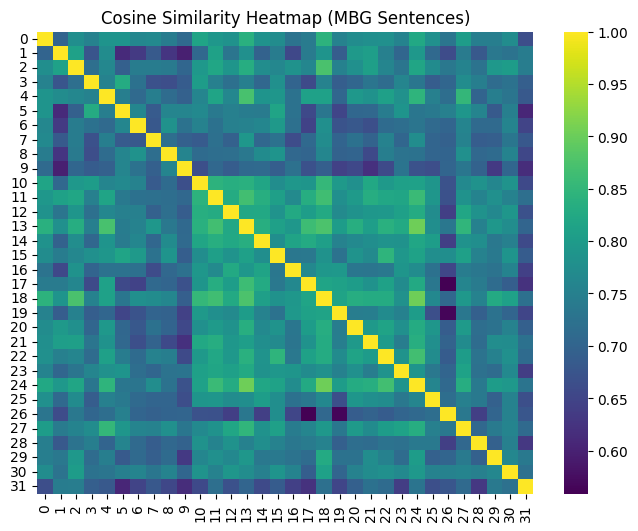

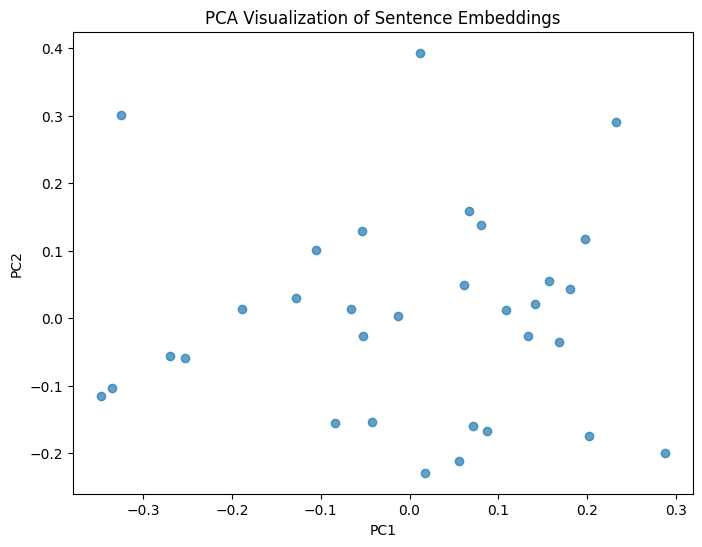

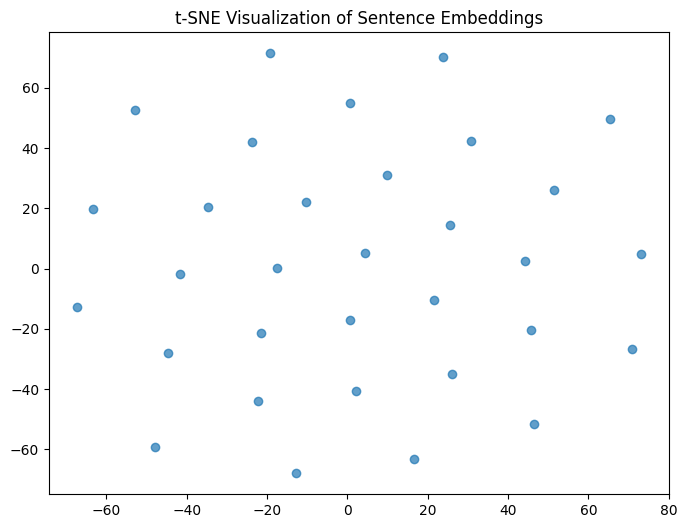

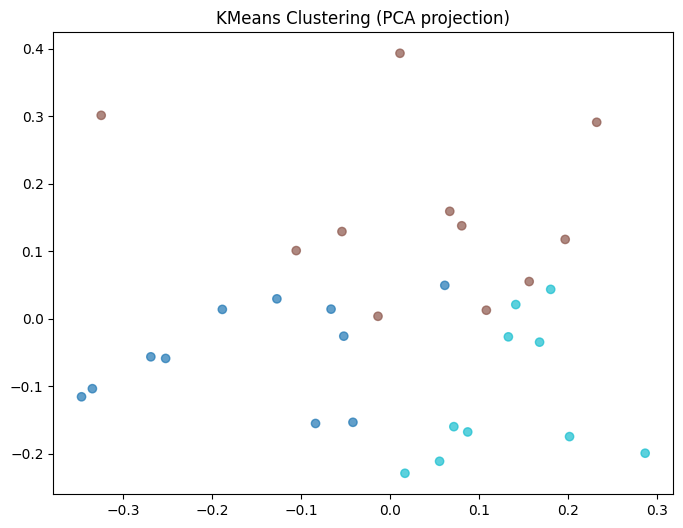


Cluster 0 examples:
['JAKARTA, KOMPAS.com - Pemerintah terus menyiapkan dan menguji coba program makan bergizi gratis yang rencananya akan dimulai pada 2 Januari 2025. Terbaru, pemerintah memiliki opsi untuk mengganti susu kemasan menjadi susu cair sebagai alternatif pengganti dalam menu program makan bergizi gratis. Menteri Sekretaris Negara (Mensesneg) Prasetyo Hadi sebelumnya mengatakan, alternatif ini mempertimbangkan susu yang menjadi salah satu komponen menu paling mahal dalam program itu. Pertimbangan ini pun menjadi salah satu catatan usai uji coba program makan bergizi gratis dilakukan selama berbulan-bulan di beberapa kota. "Jadi, kita perlu berpikir alternatif lain selain susu yang susu kemasan itu. Mungkin dengan menggunakan susu cair," kata Prasetyo di Akademi Militer Magelang, Minggu (27/10/2024). Sasar ibu hamil hingga anak sekolah Program ini bakal menyasar ibu hamil, ibu menyusui, anak balita, dan seluruh anak sekolah dari mulai PAUD sampai SMA negeri dan swasta. Kepa

In [ ]:
# --- 1. Install dependencies (if needed) ---
# pip install sentence-transformers scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# --- 2. Load MBG dataset ---
# assuming df2['Konten'] already exists
sentences = df2['Konten'].dropna().tolist()

# --- 3. Generate embeddings ---
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Embeddings shape:", embeddings.shape)
# Example: (N_sentences, 384)

# --- 4. Cosine Similarity Heatmap ---
cos_sim = cosine_similarity(embeddings)

plt.figure(figsize=(8,6))
sns.heatmap(cos_sim, cmap="viridis")
plt.title("Cosine Similarity Heatmap (MBG Sentences)")
plt.show()

# --- 5. PCA Visualization ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], alpha=0.7)
plt.title("PCA Visualization of Sentence Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# --- 6. t-SNE Visualization ---
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(tsne_result[:,0], tsne_result[:,1], alpha=0.7)
plt.title("t-SNE Visualization of Sentence Embeddings")
plt.show()

# --- 7. KMeans Clustering ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)

df2['Cluster'] = labels  # add results back to DataFrame

# Visualize clusters with PCA
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], c=labels, cmap="tab10", alpha=0.7)
plt.title("KMeans Clustering (PCA projection)")
plt.show()

# --- 8. Inspect cluster examples ---
for cluster_id in sorted(df2['Cluster'].unique()):
    print(f"\nCluster {cluster_id} examples:")
    print(df2[df2['Cluster']==cluster_id]['Konten'].head(3).tolist())



Cluster 0 → Solution
['JAKARTA, KOMPAS.com - Pemerintah terus menyiapkan dan menguji coba program makan bergizi gratis yang rencananya akan dimulai pada 2 Januari 2025. Terbaru, pemerintah memiliki opsi untuk mengganti susu kemasan menjadi susu cair sebagai alternatif pengganti dalam menu program makan bergizi gratis. Menteri Sekretaris Negara (Mensesneg) Prasetyo Hadi sebelumnya mengatakan, alternatif ini mempertimbangkan susu yang menjadi salah satu komponen menu paling mahal dalam program itu. Pertimbangan ini pun menjadi salah satu catatan usai uji coba program makan bergizi gratis dilakukan selama berbulan-bulan di beberapa kota. "Jadi, kita perlu berpikir alternatif lain selain susu yang susu kemasan itu. Mungkin dengan menggunakan susu cair," kata Prasetyo di Akademi Militer Magelang, Minggu (27/10/2024). Sasar ibu hamil hingga anak sekolah Program ini bakal menyasar ibu hamil, ibu menyusui, anak balita, dan seluruh anak sekolah dari mulai PAUD sampai SMA negeri dan swasta. Kep

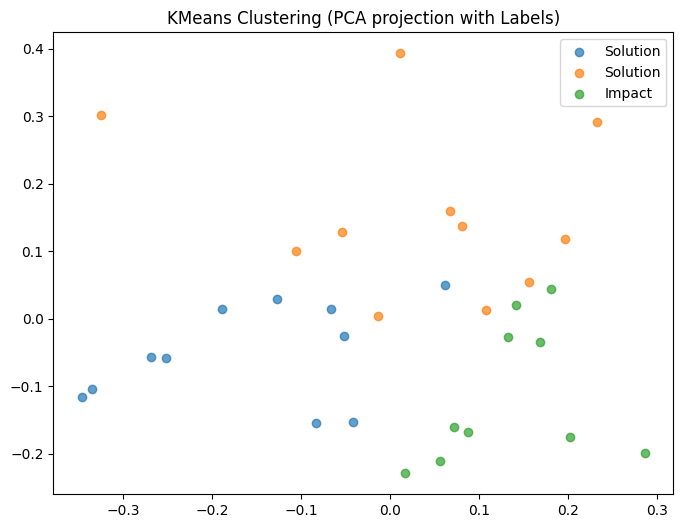

In [ ]:
# --- 7. KMeans Clustering ---
from collections import Counter

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)

df2['Cluster'] = labels  # add results back to DataFrame

# --- 8. Heuristic Cluster Labeling ---
# Define simple keyword sets (you can adjust based on your MBG dataset)
keywords_map = {
    "Challenge": ["masalah", "tantangan", "hambatan", "kesulitan", "kurang", "gagal"],
    "Solution": ["solusi", "program", "inisiatif", "kebijakan", "strategi", "dukungan"],
    "Impact": ["ekonomi", "dampak", "manfaat", "pengaruh", "hasil", "perubahan"]
}

cluster_labels = {}

for cluster_id in sorted(df2['Cluster'].unique()):
    cluster_texts = " ".join(df2[df2['Cluster']==cluster_id]['Konten'].tolist()).lower()

    scores = {label: sum(word in cluster_texts for word in words)
              for label, words in keywords_map.items()}

    best_label = max(scores, key=scores.get) if any(scores.values()) else "Other"
    cluster_labels[cluster_id] = best_label

# Map cluster numbers → descriptive labels
df2['Cluster_Label'] = df2['Cluster'].map(cluster_labels)

# --- 9. Inspect cluster examples ---
for cluster_id, label in cluster_labels.items():
    print(f"\nCluster {cluster_id} → {label}")
    print(df2[df2['Cluster']==cluster_id]['Konten'].head(3).tolist())

# --- 10. Visualize with descriptive labels ---
plt.figure(figsize=(8,6))
for cluster_id, label in cluster_labels.items():
    mask = df2['Cluster'] == cluster_id
    plt.scatter(pca_result[mask,0], pca_result[mask,1], label=label, alpha=0.7)

plt.title("KMeans Clustering (PCA projection with Labels)")
plt.legend()
plt.show()


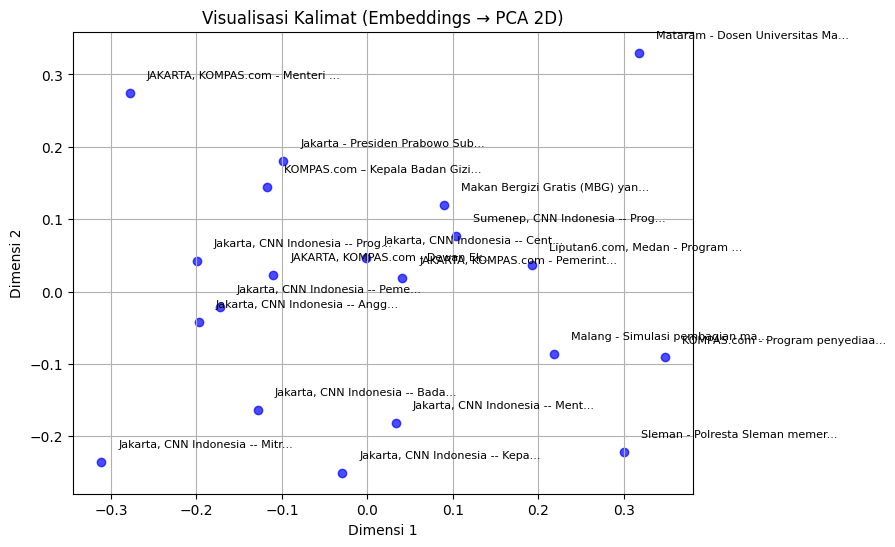

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- 1. Ambil beberapa contoh kalimat (supaya plot tidak terlalu padat) ---
sample_sentences = df2['Konten'].dropna().sample(20, random_state=42).tolist()

# --- 2. Buat embeddings ---
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sample_sentences)

# --- 3. Reduksi dimensi ke 2D (PCA) ---
pca = PCA(n_components=2)
X_2d = pca.fit_transform(embeddings)

# --- 4. Plot ---
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c="blue", alpha=0.7)

for i, text in enumerate(sample_sentences):
    plt.text(X_2d[i,0]+0.02, X_2d[i,1]+0.02, text[:30]+"...", fontsize=8)

plt.title("Visualisasi Kalimat (Embeddings → PCA 2D)")
plt.xlabel("Dimensi 1")
plt.ylabel("Dimensi 2")
plt.grid(True)
plt.show()


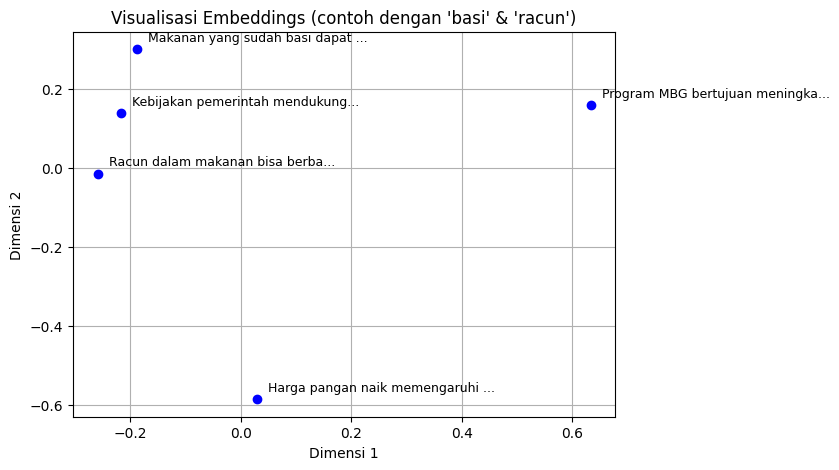

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

sentences = [
    "Makanan yang sudah basi dapat menimbulkan penyakit.",
    "Racun dalam makanan bisa berbahaya bagi kesehatan.",
    "Program MBG bertujuan meningkatkan gizi anak-anak.",
    "Kebijakan pemerintah mendukung distribusi makanan gratis.",
    "Harga pangan naik memengaruhi kondisi ekonomi keluarga."
]

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c="blue")

for i, text in enumerate(sentences):
    plt.text(X_2d[i,0]+0.02, X_2d[i,1]+0.02, text[:30]+"...", fontsize=9)

plt.title("Visualisasi Embeddings (contoh dengan 'basi' & 'racun')")
plt.xlabel("Dimensi 1")
plt.ylabel("Dimensi 2")
plt.grid(True)
plt.show()


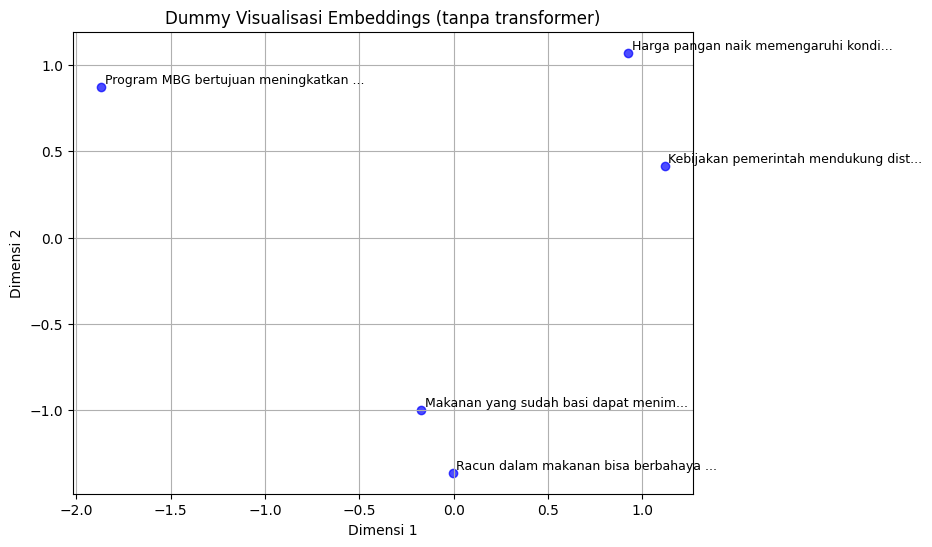

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- 1. Contoh kalimat (campuran manual + topik MBG) ---
sentences = [
    "Makanan yang sudah basi dapat menimbulkan penyakit.",
    "Racun dalam makanan bisa berbahaya bagi kesehatan.",
    "Program MBG bertujuan meningkatkan gizi anak-anak.",
    "Kebijakan pemerintah mendukung distribusi makanan gratis.",
    "Harga pangan naik memengaruhi kondisi ekonomi keluarga."
]

# --- 2. Buat dummy embeddings (random tapi stabil dengan seed) ---
np.random.seed(42)
embeddings = np.random.rand(len(sentences), 50)  # 50 dimensi dummy

# --- 3. Reduksi dimensi ke 2D (PCA) ---
pca = PCA(n_components=2)
X_2d = pca.fit_transform(embeddings)

# --- 4. Plot hasil ---
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c="blue", alpha=0.7)

for i, text in enumerate(sentences):
    plt.text(X_2d[i,0]+0.02, X_2d[i,1]+0.02, text[:35]+"...", fontsize=9)

plt.title("Dummy Visualisasi Embeddings (tanpa transformer)")
plt.xlabel("Dimensi 1")
plt.ylabel("Dimensi 2")
plt.grid(True)
plt.show()


Ukuran embeddings: (5, 384)


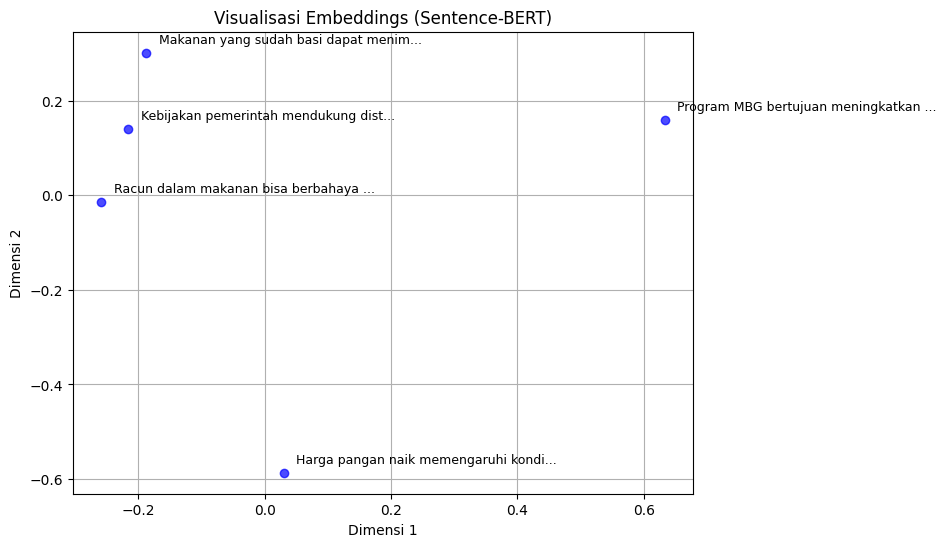

In [ ]:
# --- 1. Install library jika belum ada ---
# pip install sentence-transformers scikit-learn matplotlib

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- 2. Contoh kalimat (dengan kata 'basi' & 'racun' + topik MBG) ---
sentences = [
    "Makanan yang sudah basi dapat menimbulkan penyakit.",
    "Racun dalam makanan bisa berbahaya bagi kesehatan.",
    "Program MBG bertujuan meningkatkan gizi anak-anak.",
    "Kebijakan pemerintah mendukung distribusi makanan gratis.",
    "Harga pangan naik memengaruhi kondisi ekonomi keluarga."
]

# --- 3. Buat embeddings dengan model Sentence-BERT ---
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Ukuran embeddings:", embeddings.shape)  # contoh: (5, 384)

# --- 4. Reduksi dimensi ke 2D (PCA) ---
pca = PCA(n_components=2)
X_2d = pca.fit_transform(embeddings)

# --- 5. Plot hasil visualisasi ---
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c="blue", alpha=0.7)

for i, text in enumerate(sentences):
    plt.text(X_2d[i,0]+0.02, X_2d[i,1]+0.02, text[:35]+"...", fontsize=9)

plt.title("Visualisasi Embeddings (Sentence-BERT)")
plt.xlabel("Dimensi 1")
plt.ylabel("Dimensi 2")
plt.grid(True)
plt.show()
